In [ ]:
import sys
import subprocess
import pkgutil

def _install_if_missing(packages):
    missing = [p for p in packages if pkgutil.find_loader(p["import_name"]) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + [p["pip_name"] for p in missing])

_install_if_missing([
    {"import_name": "warp", "pip_name": "warp-lang"},
    {"import_name": "numpy", "pip_name": "numpy"},
    {"import_name": "matplotlib", "pip_name": "matplotlib"},
])

import math
import time
import numpy as np
import matplotlib.pyplot as plt
import warp as wp

wp.init()

device = "cuda:0" if wp.is_cuda_available() else "cpu"
print(f"Using Warp device: {device}")

@wp.kernel
def saxpy_kernel(a: wp.float32, x: wp.array(dtype=wp.float32), y: wp.array(dtype=wp.float32), out: wp.array(dtype=wp.float32)):
    i = wp.tid()
    out[i] = a * x[i] + y[i]

@wp.kernel
def image_sdf_kernel(width: int, height: int, pixels: wp.array(dtype=wp.float32)):
    tid = wp.tid()
    x = tid % width
    y = tid // width
    fx = 2.0 * (wp.float32(x) / wp.float32(width - 1)) - 1.0
    fy = 2.0 * (wp.float32(y) / wp.float32(height - 1)) - 1.0
    r1 = wp.sqrt((fx + 0.35) * (fx + 0.35) + fy * fy) - 0.28
    r2 = wp.sqrt((fx - 0.25) * (fx - 0.25) + (fy - 0.15) * (fy - 0.15)) - 0.18
    wave = fy + 0.25 * wp.sin(8.0 * fx)
    d = wp.min(r1, r2)
    d = wp.max(d, -wave)
    value = wp.exp(-18.0 * wp.abs(d))
    pixels[tid] = value

In [ ]:
@wp.kernel
def init_particles_kernel(
    n_particles: int,
    px0: wp.array(dtype=wp.float32),
    py0: wp.array(dtype=wp.float32),
    vx0: wp.array(dtype=wp.float32),
    vy0: wp.array(dtype=wp.float32),
    px: wp.array(dtype=wp.float32),
    py: wp.array(dtype=wp.float32),
    vx: wp.array(dtype=wp.float32),
    vy: wp.array(dtype=wp.float32),
):
    p = wp.tid()
    px[p] = px0[p]
    py[p] = py0[p]
    vx[p] = vx0[p]
    vy[p] = vy0[p]

@wp.kernel
def simulate_particles_kernel(
    n_particles: int,
    dt: wp.float32,
    gravity: wp.float32,
    damping: wp.float32,
    bounce: wp.float32,
    radius: wp.float32,
    px: wp.array(dtype=wp.float32),
    py: wp.array(dtype=wp.float32),
    vx: wp.array(dtype=wp.float32),
    vy: wp.array(dtype=wp.float32),
):
    tid = wp.tid()
    s = tid // n_particles
    p = tid % n_particles
    i0 = s * n_particles + p
    i1 = (s + 1) * n_particles + p
    x = px[i0]
    y = py[i0]
    u = vx[i0]
    v = vy[i0]
    v = v + gravity * dt
    x = x + u * dt
    y = y + v * dt
    if y < radius:
        y = radius
        v = -bounce * v
        u = damping * u
    if x < -1.0 + radius:
        x = -1.0 + radius
        u = -bounce * u
    if x > 1.0 - radius:
        x = 1.0 - radius
        u = -bounce * u
    px[i1] = x
    py[i1] = y
    vx[i1] = u
    vy[i1] = v

In [ ]:
@wp.kernel
def init_projectile_kernel(
    x_hist: wp.array(dtype=wp.float32),
    y_hist: wp.array(dtype=wp.float32),
    vx_hist: wp.array(dtype=wp.float32),
    vy_hist: wp.array(dtype=wp.float32),
    init_vx: wp.array(dtype=wp.float32),
    init_vy: wp.array(dtype=wp.float32),
):
    x_hist[0] = 0.0
    y_hist[0] = 0.0
    vx_hist[0] = init_vx[0]
    vy_hist[0] = init_vy[0]

@wp.kernel
def projectile_step_kernel(
    dt: wp.float32,
    gravity: wp.float32,
    x_hist: wp.array(dtype=wp.float32),
    y_hist: wp.array(dtype=wp.float32),
    vx_hist: wp.array(dtype=wp.float32),
    vy_hist: wp.array(dtype=wp.float32),
):
    s = wp.tid()
    x = x_hist[s]
    y = y_hist[s]
    vx = vx_hist[s]
    vy = vy_hist[s]
    vy = vy + gravity * dt
    x = x + vx * dt
    y = y + vy * dt
    if y < 0.0:
        y = 0.0
    x_hist[s + 1] = x
    y_hist[s + 1] = y
    vx_hist[s + 1] = vx
    vy_hist[s + 1] = vy

@wp.kernel
def projectile_loss_kernel(
    steps: int,
    target_x: wp.float32,
    target_y: wp.float32,
    x_hist: wp.array(dtype=wp.float32),
    y_hist: wp.array(dtype=wp.float32),
    loss: wp.array(dtype=wp.float32),
):
    dx = x_hist[steps] - target_x
    dy = y_hist[steps] - target_y
    loss[0] = dx * dx + dy * dy

In [ ]:
n = 1_000_000
a = np.float32(2.5)
x_np = np.linspace(0.0, 1.0, n, dtype=np.float32)
y_np = np.linspace(1.0, 2.0, n, dtype=np.float32)

x_wp = wp.array(x_np, dtype=wp.float32, device=device)
y_wp = wp.array(y_np, dtype=wp.float32, device=device)
out_wp = wp.empty(n, dtype=wp.float32, device=device)

t0 = time.time()
wp.launch(kernel=saxpy_kernel, dim=n, inputs=[a, x_wp, y_wp], outputs=[out_wp], device=device)
wp.synchronize()
t1 = time.time()

out_np = out_wp.numpy()
expected = a * x_np + y_np
max_err = np.max(np.abs(out_np - expected))
print(f"SAXPY runtime: {t1 - t0:.4f}s, max error: {max_err:.6e}")

width, height = 512, 512
pixels_wp = wp.empty(width * height, dtype=wp.float32, device=device)
wp.launch(kernel=image_sdf_kernel, dim=width * height, inputs=[width, height], outputs=[pixels_wp], device=device)
wp.synchronize()
img = pixels_wp.numpy().reshape(height, width)

plt.figure(figsize=(6, 6))
plt.imshow(img, origin="lower")
plt.title(f"Warp procedural field on {device}")
plt.axis("off")
plt.show()

n_particles = 256
steps = 300
dt = np.float32(0.01)
gravity = np.float32(-9.8)
damping = np.float32(0.985)
bounce = np.float32(0.82)
radius = np.float32(0.03)

/tmp/ipykernel_430/1853823813.py:6: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  missing = [p for p in packages if pkgutil.find_loader(p["import_name"]) is None]


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, CUDA driver not available (NVRTC compilation available)
   Devices:
     "cpu"      : "x86_64"
   Kernel cache:
     /root/.cache/warp/1.12.0
Using Warp device: cpu
Module __main__ c140188 load on device 'cpu' took 2525.29 ms  (compiled)
SAXPY runtime: 2.5337s, max error: 0.000000e+00


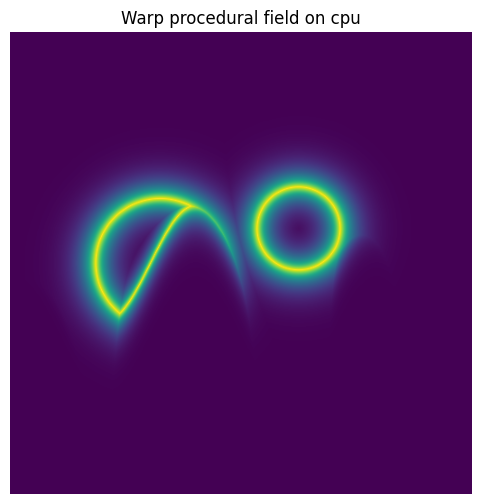

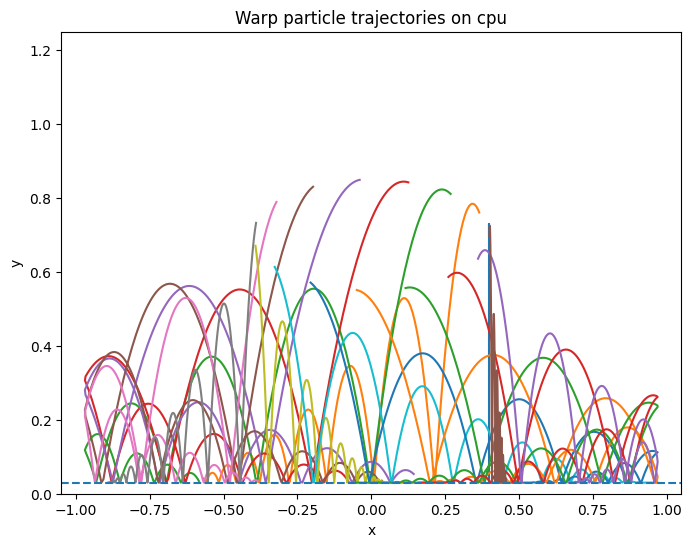

iter=00 loss=27.040167 vx=2.0000 vy=6.5000 grad=(0.0000, 0.0000)
iter=10 loss=27.040167 vx=2.0000 vy=6.5000 grad=(0.0000, 0.0000)
iter=20 loss=27.040167 vx=2.0000 vy=6.5000 grad=(0.0000, 0.0000)
iter=30 loss=27.040167 vx=2.0000 vy=6.5000 grad=(0.0000, 0.0000)
iter=40 loss=27.040167 vx=2.0000 vy=6.5000 grad=(0.0000, 0.0000)
iter=50 loss=27.040167 vx=2.0000 vy=6.5000 grad=(0.0000, 0.0000)
iter=59 loss=27.040167 vx=2.0000 vy=6.5000 grad=(0.0000, 0.0000)


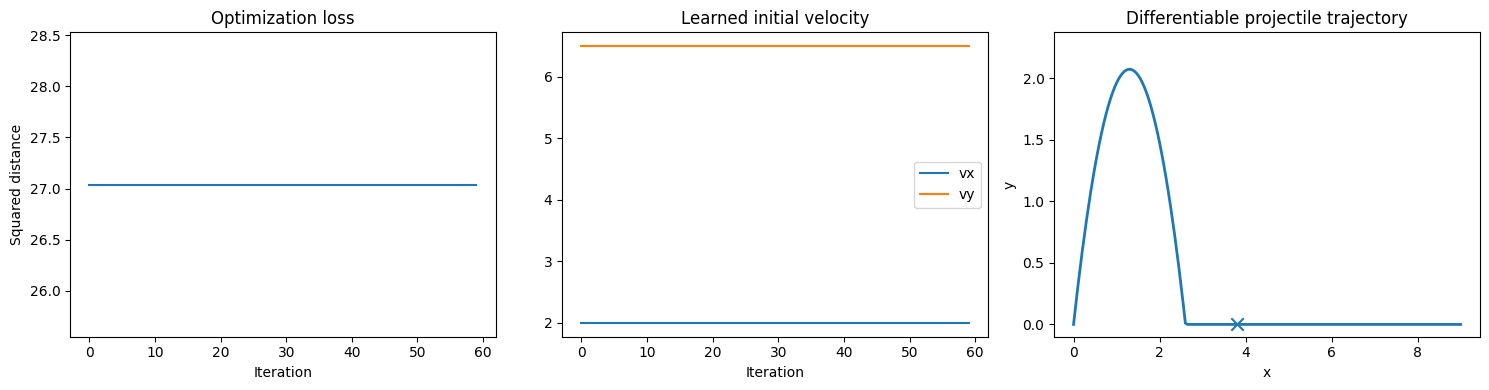

Final target miss distance: 5.200016
Optimized initial velocity: vx=2.000000, vy=6.500000


In [1]:
angles = np.linspace(0.0, 2.0 * np.pi, n_particles, endpoint=False, dtype=np.float32)
px0_np = 0.4 * np.cos(angles).astype(np.float32)
py0_np = (0.7 + 0.15 * np.sin(angles)).astype(np.float32)
vx0_np = (-0.8 * np.sin(angles)).astype(np.float32)
vy0_np = (0.8 * np.cos(angles)).astype(np.float32)

px0_wp = wp.array(px0_np, dtype=wp.float32, device=device)
py0_wp = wp.array(py0_np, dtype=wp.float32, device=device)
vx0_wp = wp.array(vx0_np, dtype=wp.float32, device=device)
vy0_wp = wp.array(vy0_np, dtype=wp.float32, device=device)

state_size = (steps + 1) * n_particles
px_wp = wp.empty(state_size, dtype=wp.float32, device=device)
py_wp = wp.empty(state_size, dtype=wp.float32, device=device)
vx_wp = wp.empty(state_size, dtype=wp.float32, device=device)
vy_wp = wp.empty(state_size, dtype=wp.float32, device=device)

wp.launch(
    kernel=init_particles_kernel,
    dim=n_particles,
    inputs=[n_particles, px0_wp, py0_wp, vx0_wp, vy0_wp],
    outputs=[px_wp, py_wp, vx_wp, vy_wp],
    device=device,
)

wp.launch(
    kernel=simulate_particles_kernel,
    dim=steps * n_particles,
    inputs=[n_particles, dt, gravity, damping, bounce, radius],
    outputs=[px_wp, py_wp, vx_wp, vy_wp],
    device=device,
)
wp.synchronize()

px_traj = px_wp.numpy().reshape(steps + 1, n_particles)
py_traj = py_wp.numpy().reshape(steps + 1, n_particles)

sample_ids = np.linspace(0, n_particles - 1, 16, dtype=int)
plt.figure(figsize=(8, 6))
for idx in sample_ids:
    plt.plot(px_traj[:, idx], py_traj[:, idx], linewidth=1.5)
plt.axhline(radius, linestyle="--")
plt.xlim(-1.05, 1.05)
plt.ylim(0.0, 1.25)
plt.title(f"Warp particle trajectories on {device}")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

proj_steps = 180
proj_dt = np.float32(0.025)
proj_g = np.float32(-9.8)
target_x = np.float32(3.8)
target_y = np.float32(0.0)

vx_value = np.float32(2.0)
vy_value = np.float32(6.5)
lr = 0.08
iters = 60

loss_history = []
vx_history = []
vy_history = []

for it in range(iters):
    init_vx_wp = wp.array(np.array([vx_value], dtype=np.float32), dtype=wp.float32, device=device, requires_grad=True)
    init_vy_wp = wp.array(np.array([vy_value], dtype=np.float32), dtype=wp.float32, device=device, requires_grad=True)

    x_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device, requires_grad=True)
    y_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device, requires_grad=True)
    vx_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device, requires_grad=True)
    vy_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device, requires_grad=True)
    loss_wp = wp.zeros(1, dtype=wp.float32, device=device, requires_grad=True)

    tape = wp.Tape()
    with tape:
        wp.launch(
            kernel=init_projectile_kernel,
            dim=1,
            inputs=[],
            outputs=[x_hist_wp, y_hist_wp, vx_hist_wp, vy_hist_wp, init_vx_wp, init_vy_wp],
            device=device,
        )
        wp.launch(
            kernel=projectile_step_kernel,
            dim=proj_steps,
            inputs=[proj_dt, proj_g],
            outputs=[x_hist_wp, y_hist_wp, vx_hist_wp, vy_hist_wp],
            device=device,
        )
        wp.launch(
            kernel=projectile_loss_kernel,
            dim=1,
            inputs=[proj_steps, target_x, target_y],
            outputs=[x_hist_wp, y_hist_wp, loss_wp],
            device=device,
        )

    tape.backward(loss=loss_wp)
    wp.synchronize()

    current_loss = float(loss_wp.numpy()[0])
    grad_vx = float(init_vx_wp.grad.numpy()[0])
    grad_vy = float(init_vy_wp.grad.numpy()[0])

    vx_value = np.float32(vx_value - lr * grad_vx)
    vy_value = np.float32(vy_value - lr * grad_vy)

    loss_history.append(current_loss)
    vx_history.append(float(vx_value))
    vy_history.append(float(vy_value))

    if it % 10 == 0 or it == iters - 1:
        print(f"iter={it:02d} loss={current_loss:.6f} vx={vx_value:.4f} vy={vy_value:.4f} grad=({grad_vx:.4f}, {grad_vy:.4f})")

final_init_vx_wp = wp.array(np.array([vx_value], dtype=np.float32), dtype=wp.float32, device=device)
final_init_vy_wp = wp.array(np.array([vy_value], dtype=np.float32), dtype=wp.float32, device=device)
x_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device)
y_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device)
vx_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device)
vy_hist_wp = wp.zeros(proj_steps + 1, dtype=wp.float32, device=device)

wp.launch(
    kernel=init_projectile_kernel,
    dim=1,
    inputs=[],
    outputs=[x_hist_wp, y_hist_wp, vx_hist_wp, vy_hist_wp, final_init_vx_wp, final_init_vy_wp],
    device=device,
)
wp.launch(
    kernel=projectile_step_kernel,
    dim=proj_steps,
    inputs=[proj_dt, proj_g],
    outputs=[x_hist_wp, y_hist_wp, vx_hist_wp, vy_hist_wp],
    device=device,
)
wp.synchronize()

x_path = x_hist_wp.numpy()
y_path = y_hist_wp.numpy()

fig = plt.figure(figsize=(15, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(loss_history)
ax1.set_title("Optimization loss")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Squared distance")

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(vx_history, label="vx")
ax2.plot(vy_history, label="vy")
ax2.set_title("Learned initial velocity")
ax2.set_xlabel("Iteration")
ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(x_path, y_path, linewidth=2)
ax3.scatter([target_x], [target_y], s=80, marker="x")
ax3.set_title("Differentiable projectile trajectory")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_ylim(-0.1, max(1.0, float(np.max(y_path)) + 0.3))

plt.tight_layout()
plt.show()

final_dx = float(x_path[-1] - target_x)
final_dy = float(y_path[-1] - target_y)
final_dist = math.sqrt(final_dx * final_dx + final_dy * final_dy)
print(f"Final target miss distance: {final_dist:.6f}")
print(f"Optimized initial velocity: vx={vx_value:.6f}, vy={vy_value:.6f}")